In [27]:
import numpy as np
import pandas as pd
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from itertools import combinations

In [31]:
df = pd.read_csv(r'C:\Users\OJH\OneDrive\SKKU\연구자료\Catalyst AI\Database\OCM_Cat.csv')

In [32]:
df.head()

,Mn_C_mol%,Cd_C_mol%,Sn_C_mol%,Ti_C_mol%,Pt_C_mol%,Ce_C_mol%,Pb_C_mol%,Bi_C_mol%,Mo_C_mol%,Cu_C_mol%,...,Preparation,Temperature,p(CH4)/p(O2),p total,X(O2),X(CH4),S(C2=),S(C2-),S(C2),Y(C2)
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Impregnation,1073,4.8,1.0,0.0,11.0,0.0,0.0,45.5,5.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Impregnation,1073,4.8,1.0,0.0,10.0,0.0,0.0,40.0,4.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Impregnation,1073,4.8,1.0,0.0,8.4,0.0,0.0,4.8,0.4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Impregnation,1073,4.8,1.0,0.0,6.8,0.0,0.0,44.1,3.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Impregnation,1073,4.8,1.0,0.0,8.0,0.0,0.0,1.3,0.1


In [33]:
X = df["Mn_C_mol%"]
y = df["Y(C2)"]
regr = OLS(y, add_constant(X)).fit()
regr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Y(C2)   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     48.03
Date:                Mon, 25 Sep 2023   Prob (F-statistic):           4.75e-12
Time:                        15:42:24   Log-Likelihood:                -15985.
No. Observations:                4759   AIC:                         3.197e+04
Df Residuals:                    4757   BIC:                         3.199e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.2391      0.101     91.431      0.000       9.041       9.437
Mn_C_mol%     24.0586      3.471      6.931      0.000      17.253      30.864
==============================================================================
Omnibus:                      901.940   Durbin-Watson:                   0.744
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4107.858
Skew:                           0.851   Prob(JB):                         0.00
Kurtosis:                       7.222   Cond. No.                         34.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

C:\Users\OJH\AppData\Local\Temp\ipykernel_47736\1771504107.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


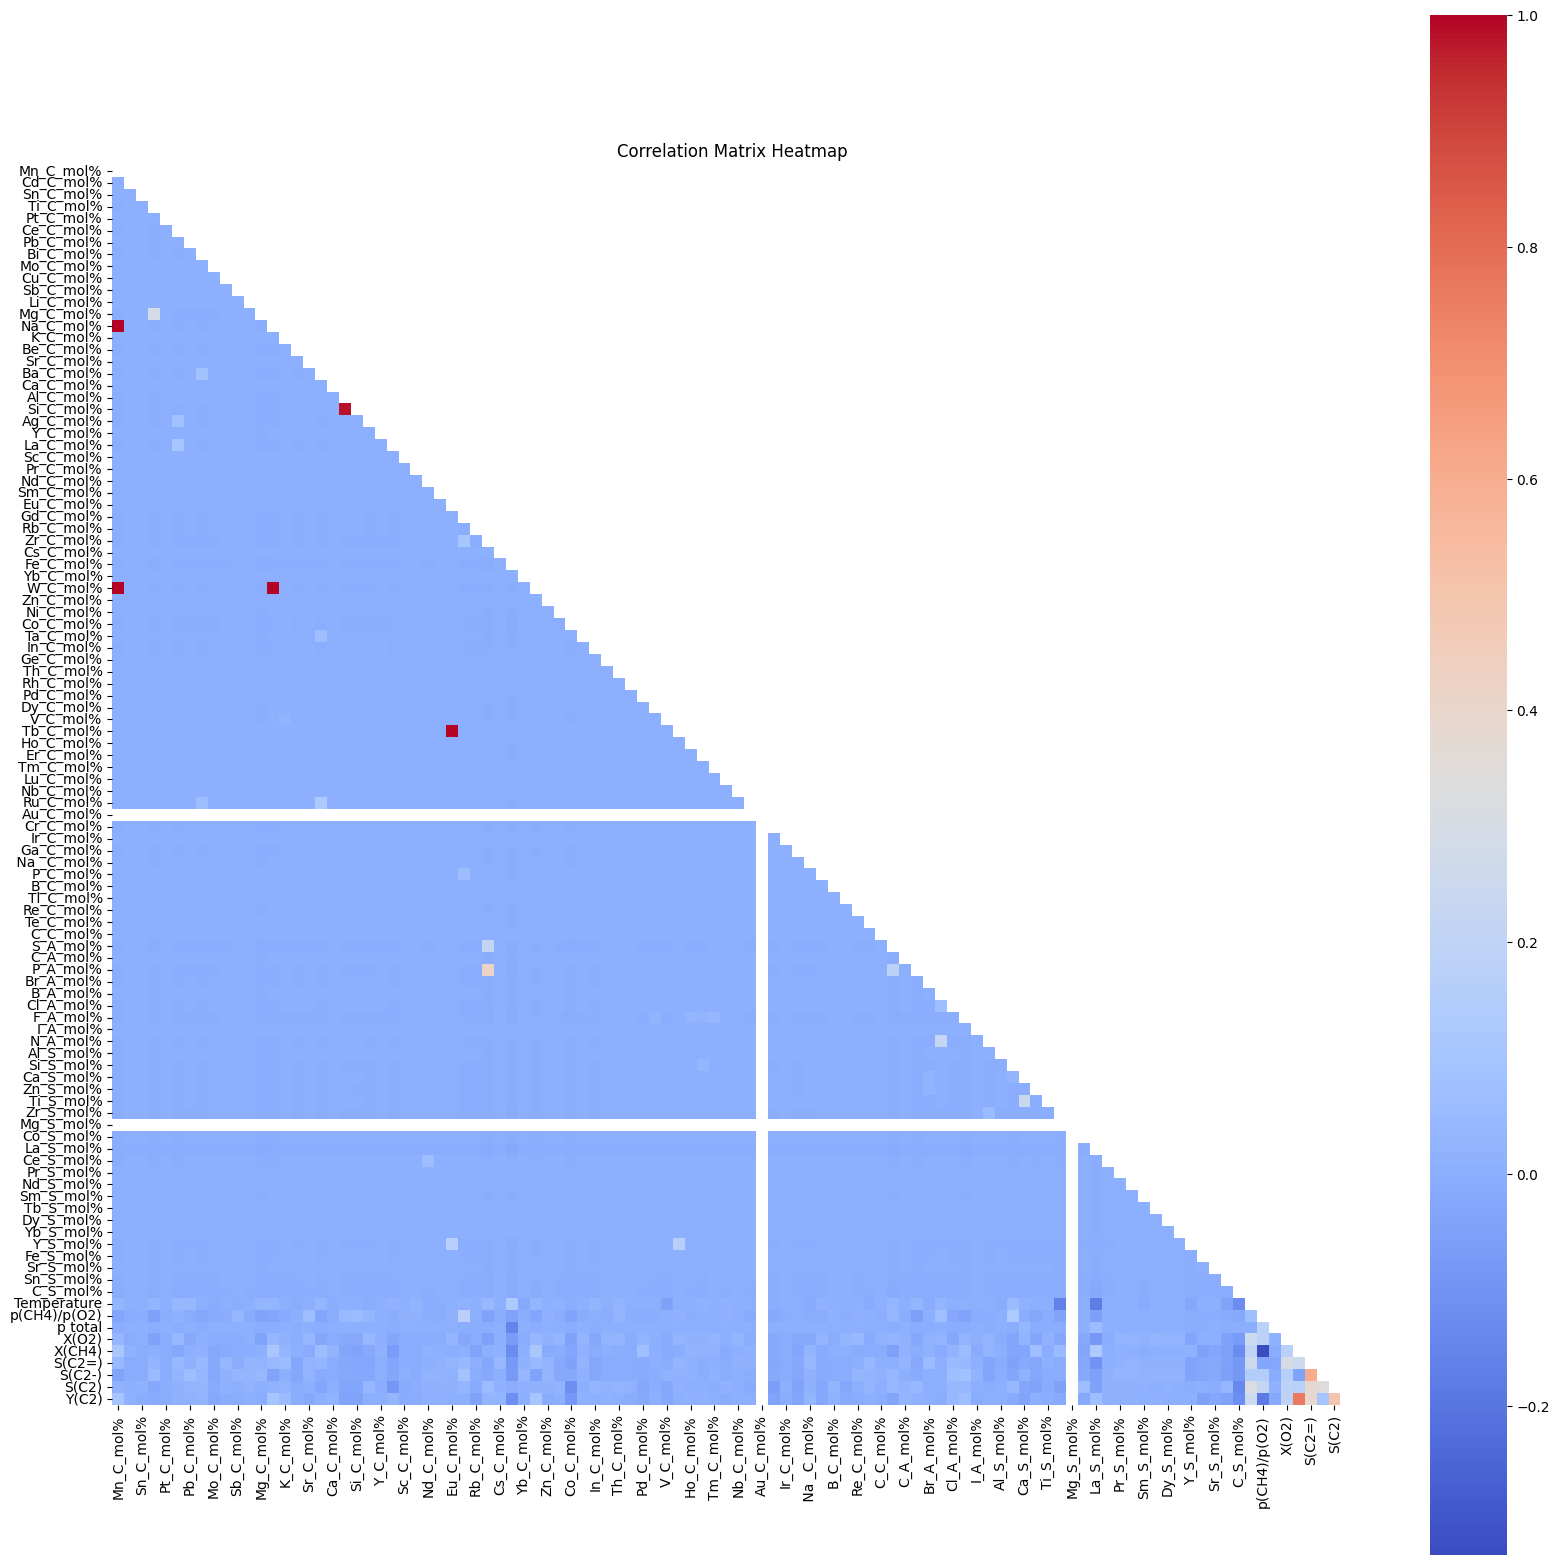

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(20, 20))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, mask=mask)

# Add title
plt.title('Correlation Matrix Heatmap')

plt.show()



In [35]:
df = pd.get_dummies(df, columns=['Preparation'], prefix=['Preparation'])
df = pd.get_dummies(df, columns=['Promotor'], prefix=['Promotor'])

df.head()

,Mn_C_mol%,Cd_C_mol%,Sn_C_mol%,Ti_C_mol%,Pt_C_mol%,Ce_C_mol%,Pb_C_mol%,Bi_C_mol%,Mo_C_mol%,Cu_C_mol%,...,Preparation_Solid-phase technique,Preparation_Therm.decomp.,Promotor_0.0,Promotor_B,Promotor_Br,Promotor_Cl,Promotor_Cl_B,Promotor_F,Promotor_P,Promotor_S
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0


In [36]:
column_names = df.columns.tolist()

column_names

['Mn_C_mol%',
 'Cd_C_mol%',
 'Sn_C_mol%',
 'Ti_C_mol%',
 'Pt_C_mol%',
 'Ce_C_mol%',
 'Pb_C_mol%',
 'Bi_C_mol%',
 'Mo_C_mol%',
 'Cu_C_mol%',
 'Sb_C_mol%',
 'Li_C_mol%',
 'Mg_C_mol%',
 'Na_C_mol%',
 'K_C_mol%',
 'Be_C_mol%',
 'Sr_C_mol%',
 'Ba_C_mol%',
 'Ca_C_mol%',
 'Al_C_mol%',
 'Si_C_mol%',
 'Ag_C_mol%',
 'Y_C_mol%',
 'La_C_mol%',
 'Sc_C_mol%',
 'Pr_C_mol%',
 'Nd_C_mol%',
 'Sm_C_mol%',
 'Eu_C_mol%',
 'Gd_C_mol%',
 'Rb_C_mol%',
 'Zr_C_mol%',
 'Cs_C_mol%',
 'Fe_C_mol%',
 'Yb_C_mol%',
 'W_C_mol%',
 'Zn_C_mol%',
 'Ni_C_mol%',
 'Co_C_mol%',
 'Ta_C_mol%',
 'In_C_mol%',
 'Ge_C_mol%',
 'Th_C_mol%',
 'Rh_C_mol%',
 'Pd_C_mol%',
 'Dy_C_mol%',
 'V_C_mol%',
 'Tb_C_mol%',
 'Ho_C_mol%',
 'Er_C_mol%',
 'Tm_C_mol%',
 'Lu_C_mol%',
 'Nb_C_mol%',
 'Ru_C_mol%',
 'Au_C_mol%',
 'Cr_C_mol%',
 'Ir_C_mol%',
 'Ga_C_mol%',
 ' Na _C_mol%',
 'P_C_mol%',
 'B_C_mol%',
 'Tl_C_mol%',
 'Re_C_mol%',
 'Te_C_mol%',
 'C_C_mol%',
 'S_A_mol%',
 'C_A_mol%',
 'P_A_mol%',
 'Br_A_mol%',
 'B_A_mol%',
 'Cl_A_mol%',
 'F_A_mol%',
 '

In [37]:
input_columns = [col for col in column_names if col not in ['X(O2)', 'X(CH4)', 'S(C2=)', 'S(C2-)', 'S(C2)', 'Y(C2)']]
output_column = 'Y(C2)'

input_columns, output_column

(['Mn_C_mol%',
  'Cd_C_mol%',
  'Sn_C_mol%',
  'Ti_C_mol%',
  'Pt_C_mol%',
  'Ce_C_mol%',
  'Pb_C_mol%',
  'Bi_C_mol%',
  'Mo_C_mol%',
  'Cu_C_mol%',
  'Sb_C_mol%',
  'Li_C_mol%',
  'Mg_C_mol%',
  'Na_C_mol%',
  'K_C_mol%',
  'Be_C_mol%',
  'Sr_C_mol%',
  'Ba_C_mol%',
  'Ca_C_mol%',
  'Al_C_mol%',
  'Si_C_mol%',
  'Ag_C_mol%',
  'Y_C_mol%',
  'La_C_mol%',
  'Sc_C_mol%',
  'Pr_C_mol%',
  'Nd_C_mol%',
  'Sm_C_mol%',
  'Eu_C_mol%',
  'Gd_C_mol%',
  'Rb_C_mol%',
  'Zr_C_mol%',
  'Cs_C_mol%',
  'Fe_C_mol%',
  'Yb_C_mol%',
  'W_C_mol%',
  'Zn_C_mol%',
  'Ni_C_mol%',
  'Co_C_mol%',
  'Ta_C_mol%',
  'In_C_mol%',
  'Ge_C_mol%',
  'Th_C_mol%',
  'Rh_C_mol%',
  'Pd_C_mol%',
  'Dy_C_mol%',
  'V_C_mol%',
  'Tb_C_mol%',
  'Ho_C_mol%',
  'Er_C_mol%',
  'Tm_C_mol%',
  'Lu_C_mol%',
  'Nb_C_mol%',
  'Ru_C_mol%',
  'Au_C_mol%',
  'Cr_C_mol%',
  'Ir_C_mol%',
  'Ga_C_mol%',
  ' Na _C_mol%',
  'P_C_mol%',
  'B_C_mol%',
  'Tl_C_mol%',
  'Re_C_mol%',
  'Te_C_mol%',
  'C_C_mol%',
  'S_A_mol%',
  'C_A_mol%',
  

In [38]:
from sklearn.model_selection import train_test_split

X = df[input_columns]
y = df[output_column]

# Split the data into training, testing, and validation sets (60%, 20%, 20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import warnings
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np


In [46]:
# Bayesian optimization을 사용한 하이퍼파라미터 튜닝을 수행할 함수
def optimize_model(model, param_bounds):
    def objective_function(**params):
        for key in params:
            if type(param_bounds[key]) is tuple:
                params[key] = int(params[key])
        model.set_params(**params)
        return -np.mean(cross_val_score(model, X_train, y_train, cv=3, scoring="neg_mean_squared_error"))

    optimizer = BayesianOptimization(f=objective_function, pbounds=param_bounds, random_state=1)
    optimizer.maximize(init_points=5, n_iter=25)
    return optimizer.max

In [47]:
# 각 모델의 하이퍼파라미터 범위 설정
param_bounds_list = [
    {'fit_intercept': (0, 1)},  # Linear Regression
    {'max_depth': (1, 50), 'min_samples_split': (2, 20)},  # Decision Tree
    {'n_neighbors': (1, 20)},  # k-NN
    {'C': (1e-6, 1e+6)},  # SVM
    {'alpha': (1e-10, 1e-1)},  # Gaussian Process
    {'max_depth': (1, 50), 'n_estimators': (10, 200)},  # Random Forests
    {'learning_rate': (0.01, 1), 'n_estimators': (50, 150)},  # XGBoost
    {'alpha': (1e-5, 1e-1)}  # ANN
]

In [48]:
# 모델 설정 (예: Linear Regression, Decision Tree 등)
models = [
    LinearRegression(),
    DecisionTreeRegressor(),
    KNeighborsRegressor(),
    SVR(),
    GaussianProcessRegressor(),
    RandomForestRegressor(),
    XGBRegressor(),
    MLPRegressor()
]

best_params = {}
for model, param_bounds in zip(models, param_bounds_list):
    best = optimize_model(model, param_bounds)
    best_params[model] = best['params']

|   iter    |  target   | fit_in... |
-------------------------------------
| 1         | 3.123e+05 | 0.417     |
| 2         | 3.123e+05 | 0.7203    |


c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\anal

| 3         | 3.123e+05 | 0.0001144 |
| 4         | 3.123e+05 | 0.3023    |
| 5         | 3.123e+05 | 0.1468    |


c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\anal

| 6         | 3.123e+05 | 0.9999    |
| 7         | 3.123e+05 | 0.9999    |
| 8         | 3.123e+05 | 0.0001419 |


...

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\anal

| 27        | 3.123e+05 | 1.0       |
| 28        | 3.123e+05 | 7.821e-06 |
| 29        | 3.123e+05 | 1.0       |


c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\utils\_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(
c:\Users\OJH\anaconda3\envs\anal

| 30        | 3.123e+05 | 5.746e-05 |
|   iter    |  target   | max_depth | min_sa... |
-------------------------------------------------
| 1         | 34.96     | 21.43     | 14.97     |
| 2         | 46.4      | 1.006     | 7.442     |
| 3         | 36.25     | 8.191     | 3.662     |
| 4         | 35.95     | 10.13     | 8.22      |
| 5         | 35.29     | 20.44     | 11.7      |
| 6         | 46.4      | 1.0       | 12.47     |
| 7         | 40.57     | 50.0      | 2.0       |
| 8         | 34.97     | 50.0      | 20.0      |
| 9         | 46.4      | 1.0       | 20.0      |
| 10        | 40.78     | 35.78     | 2.0       |
| 11        | 38.02     | 6.606     | 20.0      |
| 12        | 46.4      | 1.0       | 2.0       |
| 13        | 35.18     | 35.13     | 20.0      |
| 14        | 46.4      | 1.0       | 16.6      |
| 15        | 46.4      | 1.128     | 4.872     |
| 16        | 46.4      | 1.0       | 10.14     |
| 17        | 46.4      | 1.0       | 3.608     |
| 18        

ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\sklearn\gaussian_process\_gpr.py", line 324, in fit
    self.L_ = cholesky(K, lower=GPR_CHOLESKY_LOWER, check_finite=False)
  File "C:\Users\OJH\AppData\Roaming\Python\Python310\site-packages\scipy\linalg\decomp_cholesky.py", line 88, in cholesky
    c, lower = _cholesky(a, lower=lower, overwrite_a=overwrite_a, clean=True,
  File "C:\Users\OJH\AppData\Roaming\Python\Python310\site-packages\scipy\linal

In [ ]:
# 최적의 하이퍼파라미터를 사용하여 각 모델을 훈련하고 테스트 세트에서 성능을 평가
best_models = {}  # 최적의 모델을 저장할 딕셔너리
best_models_performance = {}  # 최적의 모델의 성능을 저장할 딕셔너리

for model, params in best_params.items():
    # 모델의 하이퍼파라미터를 최적의 값으로 설정
    for key in params:
        if type(params[key]) is float and int(params[key]) == params[key]:
            params[key] = int(params[key])
    model.set_params(**params)
    
    # 모델 훈련
    model.fit(X_train, y_train)
    
    # 테스트 세트에서 성능 평가
    y_pred_test = model.predict(X_test)
    test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # 검증 세트에서 성능 평가
    y_pred_val = model.predict(X_val)
    val_rmse = mean_squared_error(y_val, y_pred_val, squared=False)
    val_mae = mean_absolute_error(y_val, y_pred_val)
    
    # 최적의 모델과 그 성능을 딕셔너리에 저장
    best_models[type(model).__name__] = model
    best_models_performance[type(model).__name__] = {'Test RMSE': test_rmse, 'Test MAE': test_mae, 'Validation RMSE': val_rmse, 'Validation MAE': val_mae}

# 이제 best_models 딕셔너리에는 각 모델의 최적 인스턴스가 있고,
# best_models_performance 딕셔너리에는 각 모델의 테스트 세트와 검증 세트에 대한 성능 메트릭이 있습니다.

In [40]:
# Define model names and corresponding models
model_names = ["Linear Regression", "Decision Tree", "k-NN", "SVM", "Gaussian Process", "Random Forests", "XGBoost", "ANN"]
models = [LinearRegression(), DecisionTreeRegressor(), KNeighborsRegressor(), SVR(), GaussianProcessRegressor(), RandomForestRegressor(), XGBRegressor(), MLPRegressor()]
# Define Bayesian optimization hyperparameter grids
bayes_hyperparam_grids = [
    {'fit_intercept': Categorical([True, False])},  # Linear Regression
    {'max_depth': Integer(1, 50), 'min_samples_split': Integer(2, 20)},  # Decision Tree
    {'n_neighbors': Integer(1, 20), 'weights': Categorical(['uniform', 'distance'])},  # k-NN
    {'C': Real(1e-6, 1e+6, prior='log-uniform'), 'kernel': Categorical(['linear', 'rbf'])},  # SVM
    {'alpha': Real(1e-10, 1e-1, prior='log-uniform'), 'n_restarts_optimizer': Integer(0, 10), 'normalize_y': Categorical([True, False])},  # Gaussian Process
    {'max_depth': Integer(1, 50), 'n_estimators': Integer(10, 200)},  # Random Forests
    {'learning_rate': Real(0.01, 1, prior='log-uniform'), 'n_estimators': Integer(50, 150)},  # XGBoost
    {'hidden_layer_sizes': Categorical([(50,), (100,), (50, 50)]), 'activation': Categorical(['relu', 'tanh']), 'alpha': Real(1e-5, 1e-1, prior='log-uniform')}  # ANN
]


In [41]:
# Initialize dictionary to store the best models and their corresponding performance metrics
best_bayes_models = {}
best_bayes_models_performance = {}

In [43]:
# 모델별로 Bayesian optimization 실행
# Loop through each model, optimize hyperparameters using Bayesian optimization, and evaluate performance
for model_name, model, bayes_hyperparam_grid in zip(model_names, models, bayes_hyperparam_grids):
    # Skip the model if its hyperparameter grid is empty
    if not bayes_hyperparam_grid:
        print(f"Skipping {model_name} due to empty hyperparameter grid.")
        continue
    
    # Bayesian optimization for hyperparameter tuning
    bayes = BayesSearchCV(model, bayes_hyperparam_grid, n_iter=30, cv=3, n_jobs=-1)
    bayes.fit(X_train, y_train)
    # Evaluate the best Bayes-optimized model on the test set
    best_bayes_model = bayes.best_estimator_
    y_pred_test_bayes = best_bayes_model.predict(X_test)
    test_rmse_bayes = mean_squared_error(y_test, y_pred_test_bayes, squared=False)
    test_mae_bayes = mean_absolute_error(y_test, y_pred_test_bayes)
    
    # Evaluate the best Bayes-optimized model on the validation set
    y_pred_val_bayes = best_bayes_model.predict(X_val)
    val_rmse_bayes = mean_squared_error(y_val, y_pred_val_bayes, squared=False)
    val_mae_bayes = mean_absolute_error(y_val, y_pred_val_bayes)
    
    # Store the best Bayes-optimized model and its performance
    best_bayes_models[model_name] = best_bayes_model
    best_bayes_models_performance[model_name] = {'Test RMSE': test_rmse_bayes, 'Test MAE': test_mae_bayes, 'Validation RMSE': val_rmse_bayes, 'Validation MAE': val_mae_bayes}

c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning: The objective has been evaluated at this point before.
  warnings.warn("The objective has been evaluated "
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning: The objective has been evaluated at this point before.
  warnings.warn("The objective has been evaluated "
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning: The objective has been evaluated at this point before.
  warnings.warn("The objective has been evaluated "
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning: The objective has been evaluated at this point before.
  warnings.warn("The objective has been evaluated "
c:\Users\OJH\anaconda3\envs\analysis\lib\site-packages\skopt\optimizer\optimizer.py:449: UserWarning: The objective has been evaluated at this point before.
  warni

ValueError: can only convert an array of size 1 to a Python scalar

In [ ]:
# Loop through each model, optimize hyperparameters using Bayesian optimization, and evaluate performance
for model_name, model, bayes_hyperparam_grid in zip(model_names, models, bayes_hyperparam_grids):
    # Bayesian optimization for hyperparameter tuning
    bayes = BayesSearchCV(model, bayes_hyperparam_grid, n_iter=30, cv=3, n_jobs=-1)
    bayes.fit(X_train, y_train)
    
    # Evaluate the best Bayes-optimized model on the test set
    best_bayes_model = bayes.best_estimator_
    y_pred_test_bayes = best_bayes_model.predict(X_test)
    test_rmse_bayes = mean_squared_error(y_test, y_pred_test_bayes, squared=False)
    test_mae_bayes = mean_absolute_error(y_test, y_pred_test_bayes)
    
    # Evaluate the best Bayes-optimized model on the validation set
    y_pred_val_bayes = best_bayes_model.predict(X_val)
    val_rmse_bayes = mean_squared_error(y_val, y_pred_val_bayes, squared=False)
    val_mae_bayes = mean_absolute_error(y_val, y_pred_val_bayes)
    
    # Store the best Bayes-optimized model and its performance
    best_bayes_models[model_name] = best_bayes_model
    best_bayes_models_performance[model_name] = {'Test RMSE': test_rmse_bayes, 'Test MAE': test_mae_bayes, 'Validation RMSE': val_rmse_bayes, 'Validation MAE': val_mae_bayes}

In [9]:
# Find pairs of features with high absolute correlation
threshold = 0.8  # You can change the threshold value as needed
high_correlation_pairs = {}

# Iterate over the correlation matrix to find high correlation pairs
for column in correlation_matrix.columns:
    for index in correlation_matrix.index:
        if index == column:
            continue  # Skip the diagonal elements
        correlation_value = correlation_matrix.loc[index, column]
        if abs(correlation_value) > threshold:
            pair = f"{index} and {column}"
            high_correlation_pairs[pair] = correlation_value

high_correlation_pairs

{'Na_C_mol% and Mn_C_mol%': 0.9999800994697,
 'W_C_mol% and Mn_C_mol%': 0.9999254313578325,
 'Mn_C_mol% and Na_C_mol%': 0.9999800994697,
 'W_C_mol% and Na_C_mol%': 0.9998289212548467,
 'Si_C_mol% and Al_C_mol%': 0.9795463969738033,
 'Al_C_mol% and Si_C_mol%': 0.9795463969738033,
 'Tb_C_mol% and Eu_C_mol%': 0.9999999999999982,
 'Mn_C_mol% and W_C_mol%': 0.9999254313578325,
 'Na_C_mol% and W_C_mol%': 0.9998289212548467,
 'Eu_C_mol% and Tb_C_mol%': 0.9999999999999982}

In [5]:
likelihood1 = np.exp(-regr.bic/2)

In [6]:
print(np.log(likelihood1))
print(regr.llf)

-inf
-15984.546728704103


C:\Users\OJH\AppData\Local\Temp\ipykernel_28412\1353345218.py:1: RuntimeWarning: divide by zero encountered in log
  print(np.log(likelihood1))


In [7]:
x = df[["Mn_C_mol%", "p(CH4)/p(O2)"]]
y = df["Y(C2)"]
regr = OLS(y, add_constant(x)).fit()
likelihood2 = np.exp(-regr.bic/2)
regr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Y(C2)   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     108.7
Date:                Fri, 22 Sep 2023   Prob (F-statistic):           6.72e-47
Time:                        16:27:06   Log-Likelihood:                -15902.
No. Observations:                4759   AIC:                         3.181e+04
Df Residuals:                    4756   BIC:                         3.183e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.8456      0.159     68.251      0.000      10.534      11.157
Mn_C_mol%       22.4357      3.414      6.571      0.000      15.742      29.129
p(CH4)/p(O2)    -0.3544      0.027    -12.952      0.000      -0.408      -0.301
==============================================================================
Omnibus:                     1057.284   Durbin-Watson:                   0.752
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7473.196
Skew:                           0.875   Prob(JB):                         0.00
Kurtosis:                       8.884   Cond. No.                         202.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
print(likelihood2/likelihood1)

nan


C:\Users\OJH\AppData\Local\Temp\ipykernel_28412\2415017399.py:1: RuntimeWarning: invalid value encountered in double_scalars
  print(likelihood2/likelihood1)


In [9]:
X = df[["Mn_C_mol%", "p(CH4)/p(O2)","S_A_mol%", "Temperature"]]
y = df["Y(C2)"]
regr = OLS(y, add_constant(X)).fit()
bic4 = regr.bic
likelihood4 = np.exp(-bic4/2)
regr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Y(C2)   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     159.5
Date:                Fri, 22 Sep 2023   Prob (F-statistic):          2.61e-128
Time:                        16:27:06   Log-Likelihood:                -15709.
No. Observations:                4759   AIC:                         3.143e+04
Df Residuals:                    4754   BIC:                         3.146e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -9.6177      1.037     -9.276      0.000     -11.650      -7.585
Mn_C_mol%       20.1941      3.281      6.155      0.000      13.762      26.627
p(CH4)/p(O2)    -0.3915      0.026    -14.850      0.000      -0.443      -0.340
S_A_mol%        -0.0814      0.033     -2.500      0.012      -0.145      -0.018
Temperature      0.0203      0.001     19.966      0.000       0.018       0.022
==============================================================================
Omnibus:                     1301.107   Durbin-Watson:                   0.754
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12833.065
Skew:                           1.017   Prob(JB):                         0.00
Kurtosis:                      10.783   Cond. No.                     3.52e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.52e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [22]:
class BMA:
    
    def __init__(self, y, X, **kwargs):
        # Setup the basic variables.
        self.y = y
        self.X = X
        self.names = list(X.columns)
        self.nRows, self.nCols = np.shape(X)
        self.likelihoods = np.zeros(self.nCols)
        self.coefficients = np.zeros(self.nCols)
        self.probabilities = np.zeros(self.nCols)
        self.names = list(X.columns)
        # Check the max model size. (Max number of predictor variables to use in a model.)
        # This can be used to reduce the runtime but not doing an exhaustive sampling.
        if 'MaxVars' in kwargs.keys():
            self.MaxVars = kwargs['MaxVars']
        else:
            self.MaxVars = self.nCols  
        # Prepare the priors if they are provided.
        # The priors are provided for the individual regressor variables.
        # The prior for a model is the product of the priors on the variables in the model.
        if 'Priors' in kwargs.keys():
            if np.size(kwargs['Priors']) == self.nCols:
                self.Priors = kwargs['Priors']
            else:
                print("WARNING: Provided priors error.  Using equal priors instead.")
                print("The priors should be a numpy array of length equal tot he number of regressor variables.")
                self.Priors = np.ones(self.nCols)  
        else:
            self.Priors = np.ones(self.nCols)  
        
    def fit(self):
        # Perform the Bayesian Model Averaging
        
        # Initialize the sum of the likelihoods for all the models to zero.  
        # This will be the 'normalization' denominator in Bayes Theorem.
        likelighood_sum = 0
        
        # To facilitate iterating through all possible models, we start by iterating thorugh
        # the number of elements in the model.  
        for num_elements in range(1,self.MaxVars+1): 
            
            # Make a list of all index sets of models of this size.
            model_index_sets = list(combinations(list(range(self.nCols)), num_elements)) 
            
            # Iterate through all possible models of the given size.
            for model_index_set in model_index_sets:
                
                # Compute the linear regression for this given model. 
                model_X = self.X.iloc[:,list(model_index_set)]
                model_regr = OLS(self.y, model_X).fit()
                
                # Compute the likelihood (times the prior) for the model. 
                model_likelihood = np.exp(-model_regr.bic/2)*np.prod(self.Priors[list(model_index_set)])
                print("Model Variables:",model_index_set,"likelihood=",model_likelihood)
                # Add this likelihood to the running tally of likelihoods.
                likelighood_sum = likelighood_sum + model_likelihood
                
                # Add this likelihood (times the priors) to the runny tally
                # of likelihoods for each variable in the model.
                for idx, i in zip(model_index_set, range(num_elements)):
                    self.likelihoods[idx] = self.likelihoods[idx] + model_likelihood
                    self.coefficients[idx] = self.coefficients[idx] + model_regr.params[i]*model_likelihood

        # Divide by the denominator in Bayes theorem to normalize the probabilities 
        # sum to one.
        self.probabilities = self.likelihoods/likelighood_sum
        self.coefficients = self.coefficients/likelighood_sum
        
        # Return the new BMA object as an output.
        return self
        
    def summary(self):
        # Return the BMA results as a data frame for easy viewing.
        df = pd.DataFrame([self.names, list(self.probabilities), list(self.coefficients)], 
             ["Variable Name", "Probability", "Avg. Coefficient"]).T
        return df

In [23]:
X = df[["Mn_C_mol%", "p(CH4)/p(O2)","S_A_mol%", "Temperature"]]
y = df["Y(C2)"]
result = BMA(y, add_constant(X)).fit()
result.summary()

Model Variables: (0,) likelihood= 0.0
Model Variables: (1,) likelihood= 0.0
Model Variables: (2,) likelihood= 0.0
Model Variables: (3,) likelihood= 0.0
Model Variables: (4,) likelihood= 0.0
Model Variables: (0, 1) likelihood= 0.0
Model Variables: (0, 2) likelihood= 0.0
Model Variables: (0, 3) likelihood= 0.0
Model Variables: (0, 4) likelihood= 0.0
Model Variables: (1, 2) likelihood= 0.0
Model Variables: (1, 3) likelihood= 0.0
Model Variables: (1, 4) likelihood= 0.0
Model Variables: (2, 3) likelihood= 0.0
Model Variables: (2, 4) likelihood= 0.0
Model Variables: (3, 4) likelihood= 0.0
Model Variables: (0, 1, 2) likelihood= 0.0
Model Variables: (0, 1, 3) likelihood= 0.0
Model Variables: (0, 1, 4) likelihood= 0.0
Model Variables: (0, 2, 3) likelihood= 0.0
Model Variables: (0, 2, 4) likelihood= 0.0
Model Variables: (0, 3, 4) likelihood= 0.0
Model Variables: (1, 2, 3) likelihood= 0.0
Model Variables: (1, 2, 4) likelihood= 0.0
Model Variables: (1, 3, 4) likelihood= 0.0
Model Variables: (2, 3,

C:\Users\OJH\AppData\Local\Temp\ipykernel_28412\167356267.py:67: RuntimeWarning: invalid value encountered in true_divide
  self.probabilities = self.likelihoods/likelighood_sum
C:\Users\OJH\AppData\Local\Temp\ipykernel_28412\167356267.py:68: RuntimeWarning: invalid value encountered in true_divide
  self.coefficients = self.coefficients/likelighood_sum


,Variable Name,Probability,Avg. Coefficient
0,const,NaN,NaN
1,Mn_C_mol%,NaN,NaN
2,p(CH4)/p(O2),NaN,NaN
3,S_A_mol%,NaN,NaN
4,Temperature,NaN,NaN
